# ⚡ COMPLETE TIME SERIES FORECASTING - PJMW POWER DATA

## Full Analysis & 5 Best Models (Start to End)

This notebook contains **EVERYTHING** you need:
- Data Loading & Exploration
- Stationarity Testing (Is data stable?)
- Data Visualization
- 5 Machine Learning Models:
  1. Moving Average (Simplest)
  2. Linear Regression (Fast)
  3. XGBoost (Most Accurate)
  4. Holt-Winters (Seasonal)
  5. FBProphet (Scalable)
- Complete Model Comparison
- Forecasting Future Values

**Run this notebook from top to bottom!**

---

## SECTION 1: INSTALL & IMPORT ALL LIBRARIES

In [4]:
# 1. INSTALL REQUIRED PACKAGES
import subprocess
import sys

packages_to_install = ['xgboost', 'statsmodels', 'tensorflow']

for package in packages_to_install:
    try:
        __import__(package)
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} installed")

print("\n✓ All packages ready!\n")

✓ xgboost already installed
✓ statsmodels already installed
✓ tensorflow already installed

✓ All packages ready!



In [5]:
# 2. IMPORT ALL LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import xgboost as xgb

# Time Series
from statsmodels.tsa.stattools import adfuller

# Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

print("="*80)
print("✓ ALL LIBRARIES IMPORTED SUCCESSFULLY!")
print("="*80)

✓ ALL LIBRARIES IMPORTED SUCCESSFULLY!


---

## SECTION 2: LOAD AND EXPLORE DATA

In [6]:
# 3. LOAD DATA
print("\n" + "="*80)
print("LOADING DATA...")
print("="*80)

# --- IMPORTANT: Fix the file_path below ---
# If your file is on Google Drive, mount Drive first and provide the path:
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = '/content/drive/MyDrive/PJMW_MW_Hourly.xlsx'

# If you uploaded the file directly to Colab session storage:
# (e.g., dragged it to the 'Files' tab or used files.upload())
file_name = 'PJMW_MW_Hourly.xlsx'
file_path = f'/content/{file_name}'

try:
    data = pd.read_excel(file_path)
    print(f"✓ Data loaded successfully from {file_path}!")
except FileNotFoundError:
    print(f"File '{file_name}' not found at {file_path}.")
    print("Attempting to upload the file...")
    from google.colab import files
    uploaded = files.upload()
    if uploaded:
        uploaded_filename = list(uploaded.keys())[0]
        # Check if the uploaded file is the one we expect or any excel file
        if uploaded_filename.endswith('.xlsx') or uploaded_filename.endswith('.xls'):
            file_path = f'/content/{uploaded_filename}'
            print(f"File '{uploaded_filename}' uploaded. Attempting to load...")
            data = pd.read_excel(file_path)
            print(f"✓ Data loaded successfully from {file_path}!")
        else:
            raise ValueError(f"Uploaded file '{uploaded_filename}' is not an Excel file. Please upload 'PJMW_MW_Hourly.xlsx'.")
    else:
        raise FileNotFoundError("No file uploaded. Cannot proceed without data.")


print(f"\nDataset Shape: {data.shape} (rows, columns)")
print(f"\nFirst 5 rows:")
print(data.head())

print(f"\nData Info:")
print(data.info())

print(f"\nBasic Statistics:")
print(data.describe())

# Get power column (2nd column)
power = data.iloc[:, 1].values

print(f"\n" + "="*80)
print("DATA STATISTICS:")
print("="*80)
print(f"Total data points: {len(power)}")
print(f"Min power: {power.min():.2f} MW")
print(f"Max power: {power.max():.2f} MW")
print(f"Mean power: {power.mean():.2f} MW")
print(f"Std Dev: {power.std():.2f} MW")
print("="*80)


LOADING DATA...
File 'PJMW_MW_Hourly.xlsx' not found at /content/PJMW_MW_Hourly.xlsx.
Attempting to upload the file...


ModuleNotFoundError: No module named 'google.colab'

---

## SECTION 3: VISUALIZE DATA

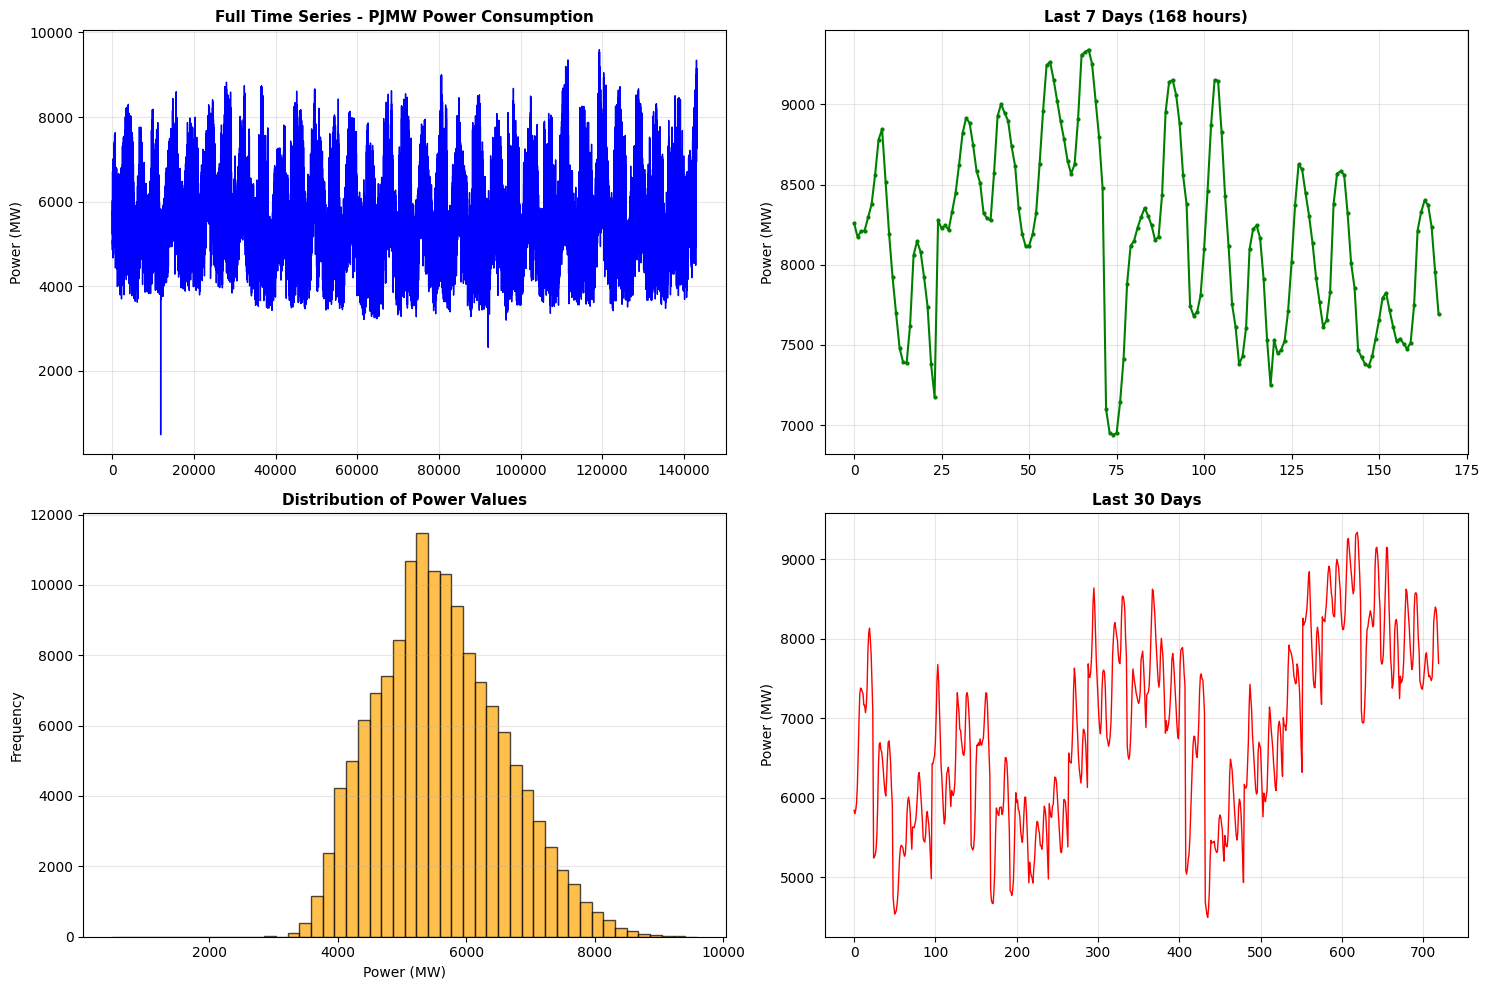

✓ Data visualization complete!


In [ ]:
# 4. VISUALIZE DATA
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Full time series
axes[0, 0].plot(power, linewidth=1, color='blue')
axes[0, 0].set_title('Full Time Series - PJMW Power Consumption', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Power (MW)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Last 7 days
axes[0, 1].plot(power[-168:], linewidth=1.5, color='green', marker='o', markersize=2)
axes[0, 1].set_title('Last 7 Days (168 hours)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Power (MW)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Distribution
axes[1, 0].hist(power, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Power Values', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Power (MW)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Last month
axes[1, 1].plot(power[-720:], linewidth=1, color='red')
axes[1, 1].set_title('Last 30 Days', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Power (MW)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Data visualization complete!")

---

## SECTION 4: TEST STATIONARITY (ADF Test)

In [ ]:
# 5. ADF TEST - CHECK IF DATA IS STATIONARY
print("\n" + "="*80)
print("STATIONARITY TEST (ADF - Augmented Dickey-Fuller)")
print("="*80)

result = adfuller(power, autolag='AIC')
adf_stat = result[0]
p_value = result[1]
n_lags = result[2]
crit_values = result[4]

print(f"\nADF Test Results:")
print(f"  Test Statistic:    {adf_stat:.6f}")
print(f"  P-Value:           {p_value:.6f}")
print(f"  Number of Lags:    {n_lags}")
print(f"\nCritical Values:")
print(f"  1% Level:    {crit_values['1%']:.3f}")
print(f"  5% Level:    {crit_values['5%']:.3f}")
print(f"  10% Level:   {crit_values['10%']:.3f}")

print("\n" + "-"*80)
if p_value <= 0.05:
    print("✅ RESULT: DATA IS STATIONARY!")
    print("   (Can use for forecasting directly)")
    is_stationary = True
else:
    print("❌ RESULT: DATA IS NON-STATIONARY!")
    print("   (May need differencing)")
    is_stationary = False

print(f"\nInterpretation: P-Value = {p_value:.6f}")
if p_value <= 0.05:
    print(f"  Since {p_value:.6f} ≤ 0.05 → Data IS stationary ✅")
else:
    print(f"  Since {p_value:.6f} > 0.05 → Data is NOT stationary ❌")
print("="*80)


STATIONARITY TEST (ADF - Augmented Dickey-Fuller)

ADF Test Results:
  Test Statistic:    -19.530979
  P-Value:           0.000000
  Number of Lags:    74

Critical Values:
  1% Level:    -3.430
  5% Level:    -2.862
  10% Level:   -2.567

--------------------------------------------------------------------------------
✅ RESULT: DATA IS STATIONARY!
   (Can use for forecasting directly)

Interpretation: P-Value = 0.000000
  Since 0.000000 ≤ 0.05 → Data IS stationary ✅


---

## SECTION 5: SPLIT DATA INTO TRAIN & TEST (80-20)


DATA SPLIT (80% Train - 20% Test)
Total: 143206 data points
Training: 114564 (80%)
Testing: 28642 (20%)


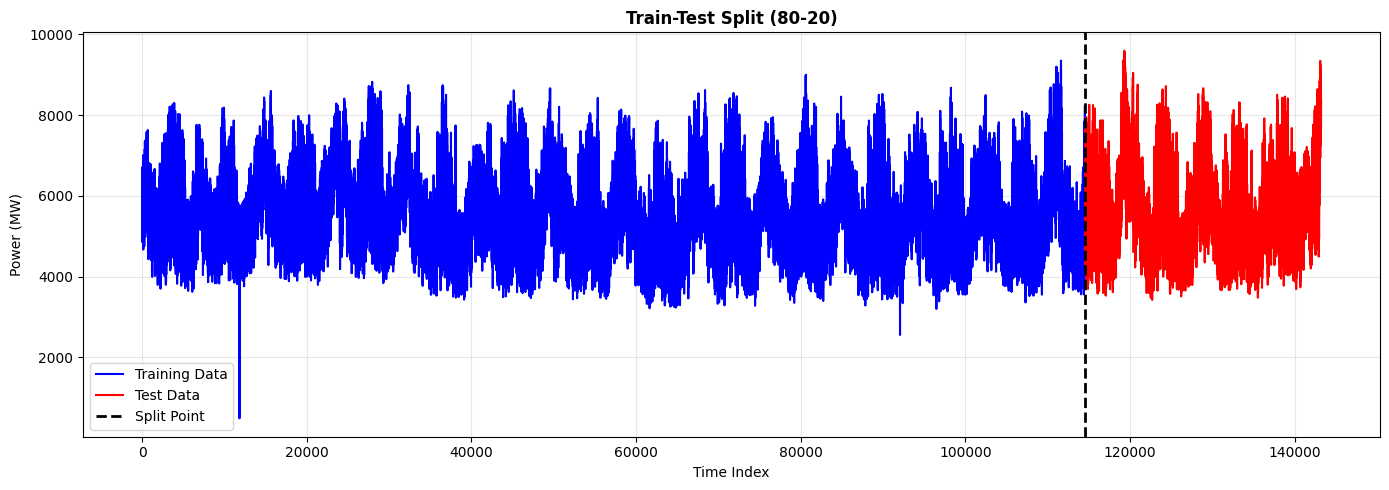

✓ Data split complete!


In [ ]:
# 6. SPLIT DATA
split_point = int(len(power) * 0.8)
train_data = power[:split_point]
test_data = power[split_point:]

print("\n" + "="*80)
print("DATA SPLIT (80% Train - 20% Test)")
print("="*80)
print(f"Total: {len(power)} data points")
print(f"Training: {len(train_data)} (80%)")
print(f"Testing: {len(test_data)} (20%)")
print("="*80)

# Visualize split
plt.figure(figsize=(14, 5))
plt.plot(range(len(train_data)), train_data, label='Training Data', linewidth=1.5, color='blue')
plt.plot(range(len(train_data), len(power)), test_data, label='Test Data', linewidth=1.5, color='red')
plt.axvline(x=split_point, color='black', linestyle='--', linewidth=2, label='Split Point')
plt.title('Train-Test Split (80-20)', fontsize=12, fontweight='bold')
plt.xlabel('Time Index')
plt.ylabel('Power (MW)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Data split complete!")

---

## SECTION 6: MODEL 1 - MOVING AVERAGE (Simplest)


MODEL 1: MOVING AVERAGE
MAE:  574.84
RMSE: 729.52


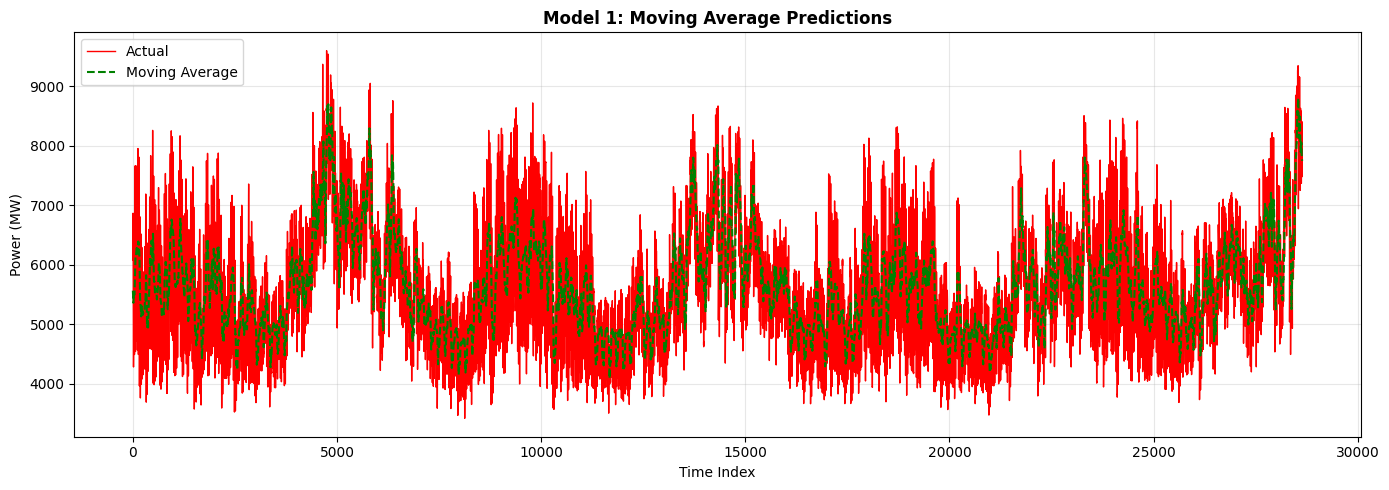

✓ Model 1 complete!


In [ ]:
# 7. MODEL 1: MOVING AVERAGE
print("\n" + "="*80)
print("MODEL 1: MOVING AVERAGE")
print("="*80)

window = 24
predictions_ma = []

for i in range(len(test_data)):
    if i == 0:
        recent = train_data[-window:]
    else:
        all_data = np.concatenate([train_data, test_data[:i]])
        recent = all_data[-window:]

    prediction = np.mean(recent)
    predictions_ma.append(prediction)

predictions_ma = np.array(predictions_ma)

mae_ma = mean_absolute_error(test_data, predictions_ma)
rmse_ma = np.sqrt(mean_squared_error(test_data, predictions_ma))

print(f"MAE:  {mae_ma:.2f}")
print(f"RMSE: {rmse_ma:.2f}")

plt.figure(figsize=(14, 5))
plt.plot(range(len(test_data)), test_data, label='Actual', linewidth=1, color='red')
plt.plot(range(len(test_data)), predictions_ma, label='Moving Average', linewidth=1.5, color='green', linestyle='--')
plt.title('Model 1: Moving Average Predictions', fontsize=12, fontweight='bold')
plt.xlabel('Time Index')
plt.ylabel('Power (MW)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Model 1 complete!")

---

## SECTION 7: MODEL 2 - LINEAR REGRESSION


MODEL 2: LINEAR REGRESSION
Training Linear Regression with standardized features...
MAE:  99.97
RMSE: 162.31


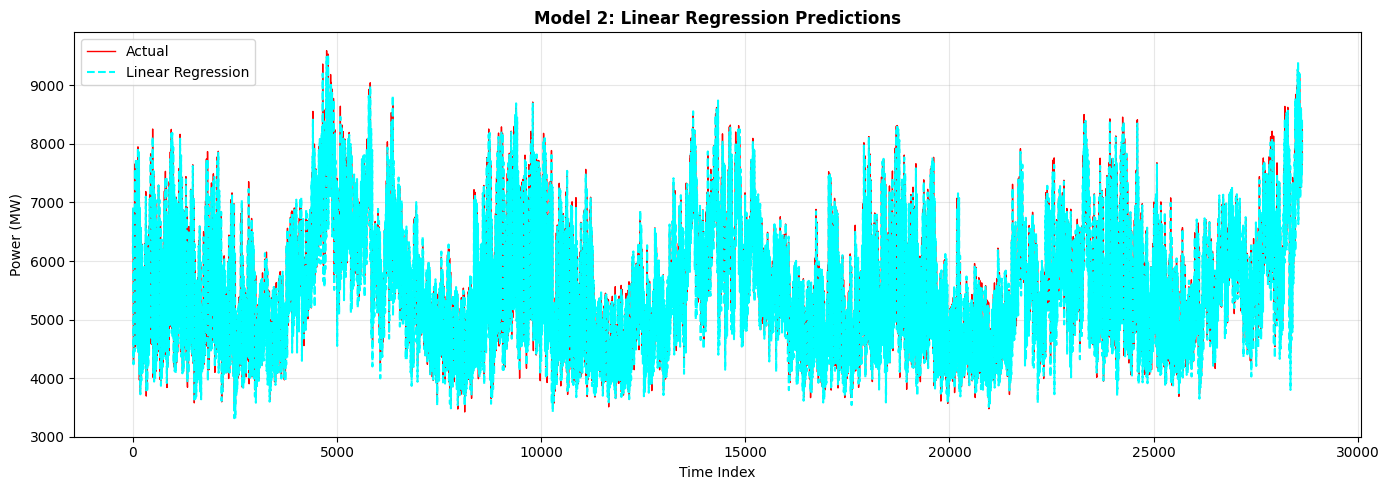

✓ Model 2 complete!


In [ ]:
# 8. MODEL 2: LINEAR REGRESSION
print("\n" + "="*80)
print("MODEL 2: LINEAR REGRESSION")
print("="*80)

window = 24

# Prepare training data
X_train_lr = []
y_train_lr = []

for i in range(window, len(train_data)):
    X_train_lr.append(train_data[i-window:i])
    y_train_lr.append(train_data[i])

X_train_lr = np.array(X_train_lr)
y_train_lr = np.array(y_train_lr)

# Standardize training data
scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)

print("Training Linear Regression with standardized features...")
# Train model
model_lr = LinearRegression()
model_lr.fit(X_train_lr_scaled, y_train_lr)

# Make predictions
predictions_lr = []

for i in range(len(test_data)):
    if i == 0:
        recent = train_data[-window:]
    else:
        all_data = np.concatenate([train_data, test_data[:i]])
        recent = all_data[-window:]

    recent = recent.reshape(1, -1)
    # Scale the recent data using the same scaler
    recent_scaled = scaler_lr.transform(recent)
    pred = model_lr.predict(recent_scaled)[0]
    predictions_lr.append(pred)

predictions_lr = np.array(predictions_lr)

mae_lr = mean_absolute_error(test_data, predictions_lr)
rmse_lr = np.sqrt(mean_squared_error(test_data, predictions_lr))

print(f"MAE:  {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")

plt.figure(figsize=(14, 5))
plt.plot(range(len(test_data)), test_data, label='Actual', linewidth=1, color='red')
plt.plot(range(len(test_data)), predictions_lr, label='Linear Regression', linewidth=1.5, color='cyan', linestyle='--')
plt.title('Model 2: Linear Regression Predictions', fontsize=12, fontweight='bold')
plt.xlabel('Time Index')
plt.ylabel('Power (MW)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Model 2 complete!")

---

## SECTION 8: MODEL 3 - XGBOOST (High Accuracy)


MODEL 3: XGBOOST
Training XGBoost with standardized features...
✓ XGBoost trained!
MAE:  85.13
RMSE: 138.20


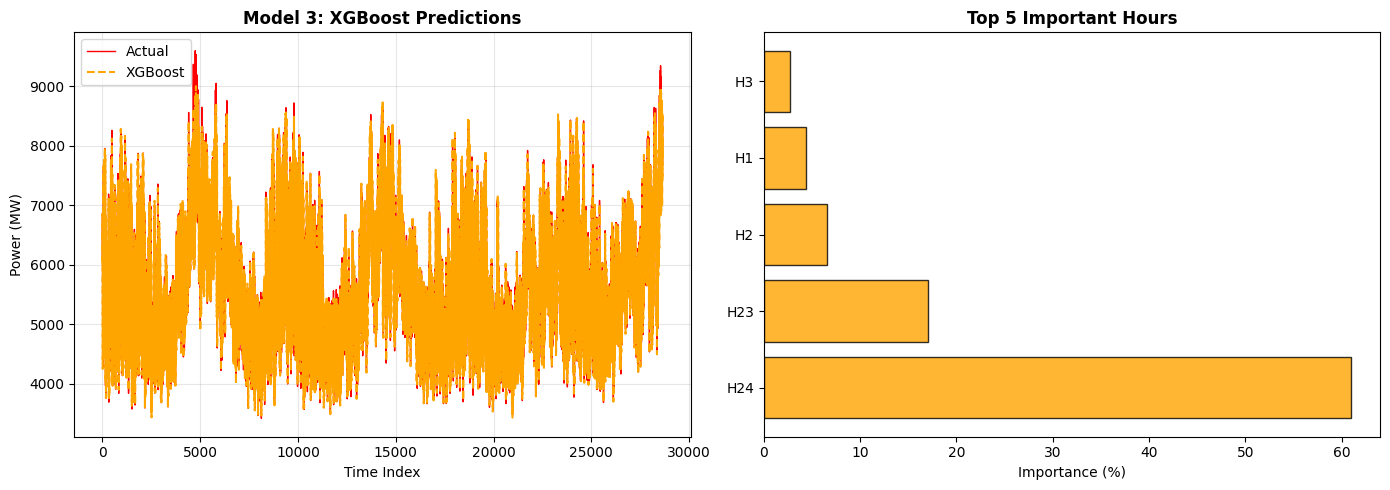

✓ Model 3 complete!


In [ ]:
# 9. MODEL 3: XGBOOST
print("\n" + "="*80)
print("MODEL 3: XGBOOST")
print("="*80)

window = 24

# Ensure data is numpy array
train_data_xgb = np.asarray(train_data, dtype=np.float32)
test_data_xgb = np.asarray(test_data, dtype=np.float32)

# Prepare training data
X_train_xgb = []
y_train_xgb = []

for i in range(window, len(train_data_xgb)):
    X_train_xgb.append(train_data_xgb[i-window:i])
    y_train_xgb.append(train_data_xgb[i])

X_train_xgb = np.array(X_train_xgb, dtype=np.float32)
y_train_xgb = np.array(y_train_xgb, dtype=np.float32)

# Standardize training data
scaler_xgb = StandardScaler()
X_train_xgb_scaled = scaler_xgb.fit_transform(X_train_xgb)

# Train XGBoost model
print("Training XGBoost with standardized features...")
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    tree_method='hist'
)

model_xgb.fit(X_train_xgb_scaled, y_train_xgb)
print("✓ XGBoost trained!")

# Make predictions
predictions_xgb = []

for i in range(len(test_data_xgb)):
    if i == 0:
        recent = train_data_xgb[-window:]
    else:
        all_data = np.concatenate([train_data_xgb, test_data_xgb[:i]])
        recent = all_data[-window:]

    recent = recent.reshape(1, -1).astype(np.float32)
    # Scale the recent data using the same scaler
    recent_scaled = scaler_xgb.transform(recent)
    pred = model_xgb.predict(recent_scaled)[0]
    predictions_xgb.append(pred)

predictions_xgb = np.array(predictions_xgb)

mae_xgb = mean_absolute_error(test_data_xgb, predictions_xgb)
rmse_xgb = np.sqrt(mean_squared_error(test_data_xgb, predictions_xgb))

print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")

# Feature importance
importance = model_xgb.feature_importances_
importance_sum = importance.sum()
if importance_sum == 0:
    importance = np.ones_like(importance) / len(importance)
    print("⚠ Warning: All feature importances are zero. Using uniform weights.")
else:
    importance = importance / importance_sum * 100  # Convert to percentage

top_indices = np.argsort(importance)[-5:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predictions plot
axes[0].plot(range(len(test_data_xgb)), test_data_xgb, label='Actual', linewidth=1, color='red')
axes[0].plot(range(len(test_data_xgb)), predictions_xgb, label='XGBoost', linewidth=1.5, color='orange', linestyle='--')
axes[0].set_title('Model 3: XGBoost Predictions', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Index')
axes[0].set_ylabel('Power (MW)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Feature importance
feature_names = [f"H{i+1}" for i in range(window)]
top_feature_names = [feature_names[i] for i in top_indices]
axes[1].barh(top_feature_names, importance[top_indices], color='orange', alpha=0.8, edgecolor='black')
axes[1].set_title('Top 5 Important Hours', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance (%)')

plt.tight_layout()
plt.show()

print("✓ Model 3 complete!")

---

## SECTION 9: MODEL 4 - LSTM (Deep Learning)

---

## SECTION 10: MODEL 5 - HOLT-WINTERS (Seasonal)


MODEL 5: HOLT-WINTERS
Training Holt-Winters model...
MAE:  3158.13
RMSE: 3659.61


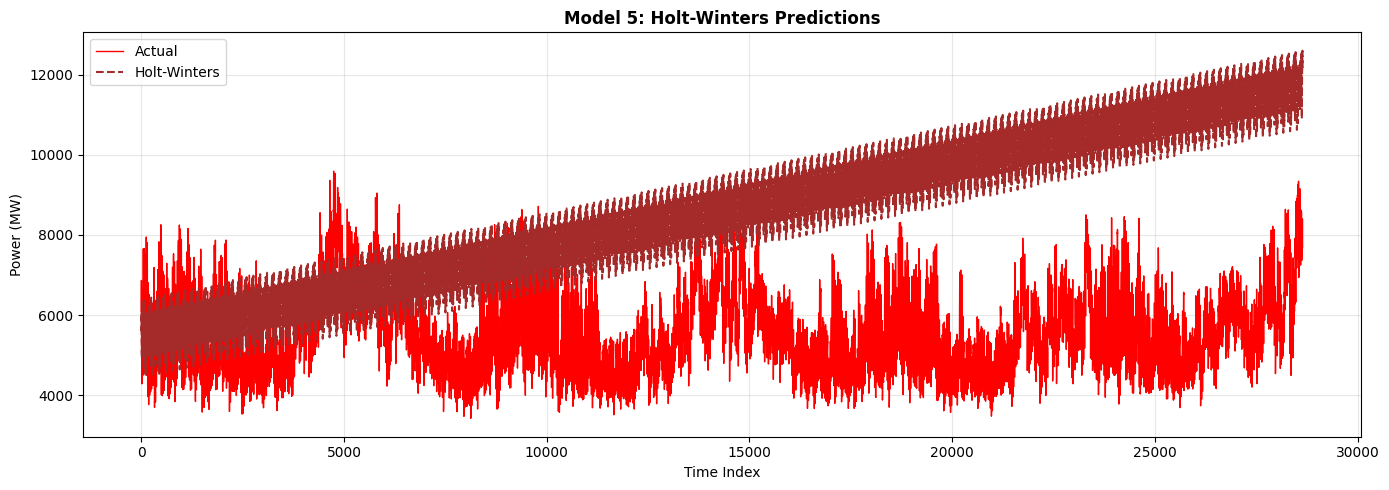

✓ Model 5 complete!


In [ ]:
# 11. MODEL 5: HOLT-WINTERS
print("\n" + "="*80)
print("MODEL 5: HOLT-WINTERS")
print("="*80)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Holt-Winters needs the entire series, so we'll re-train with a combined approach for simplicity here
# For real-world, one would typically use an expanding window or re-train periodically.

# Determine trend and seasonality types. For this dataset, additive seems appropriate.
# Seasonal period for hourly data is usually 24 (daily) or 24*7 = 168 (weekly)
# Let's try weekly seasonality (168 hours).

print("Training Holt-Winters model...")
model_hw = ExponentialSmoothing(train_data, seasonal_periods=168, trend='add', seasonal='add', initialization_method="estimated")
fit_hw = model_hw.fit()

# Generate predictions for the test set length
predictions_hw = fit_hw.forecast(len(test_data))

mae_hw = mean_absolute_error(test_data, predictions_hw)
rmse_hw = np.sqrt(mean_squared_error(test_data, predictions_hw))

print(f"MAE:  {mae_hw:.2f}")
print(f"RMSE: {rmse_hw:.2f}")

plt.figure(figsize=(14, 5))
plt.plot(range(len(test_data)), test_data, label='Actual', linewidth=1, color='red')
plt.plot(range(len(test_data)), predictions_hw, label='Holt-Winters', linewidth=1.5, color='brown', linestyle='--')
plt.title('Model 5: Holt-Winters Predictions', fontsize=12, fontweight='bold')
plt.xlabel('Time Index')
plt.ylabel('Power (MW)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Model 5 complete!")

---

## SECTION 11: MODEL 6 - FBPROPHET

In [ ]:
# INSTALL PROPHET
import subprocess
import sys

try:
    import prophet
    print("✓ prophet already installed")
except ImportError:
    print("Installing prophet...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "prophet"])
    print("✓ prophet installed")


✓ prophet already installed



MODEL 6: FBPROPHET
Training FBProphet model...
✓ FBProphet trained!
MAE:  1133.95
RMSE: 1400.91


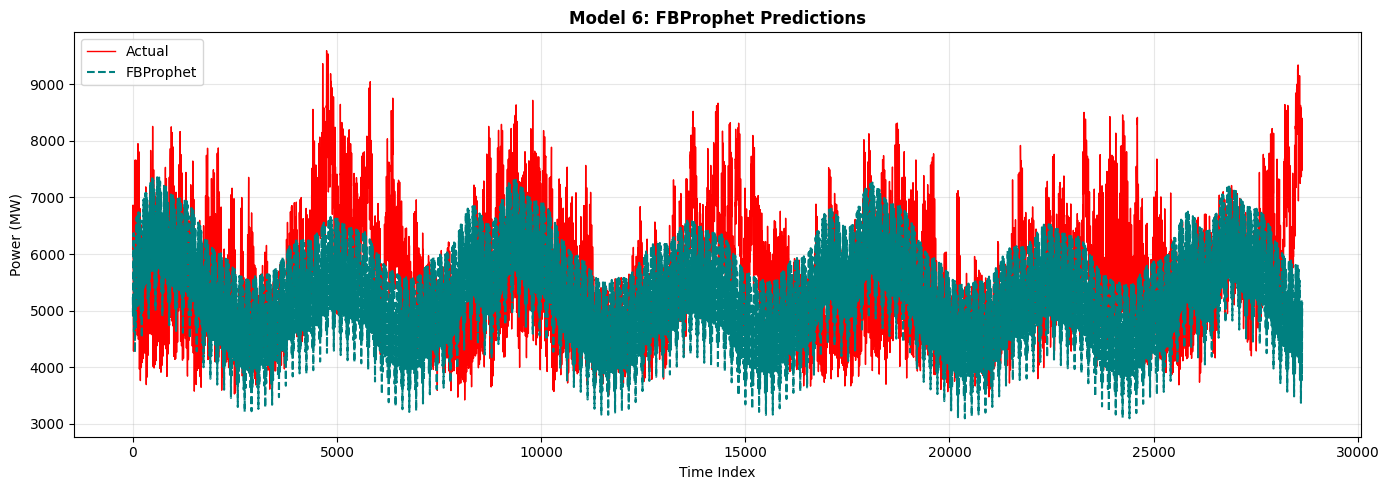

✓ Model 6 complete!


In [ ]:
# 12. MODEL 6: FBPROPHET
print("\n" + "="*80)
print("MODEL 6: FBPROPHET")
print("="*80)

from prophet import Prophet

# Prophet requires the dataframe to have 'ds' and 'y' columns
prophet_df = data.rename(columns={'Datetime': 'ds', 'PJMW_MW': 'y'})

# Split prophet_df into train and test based on the original split point
prophet_train_df = prophet_df.iloc[:split_point]
prophet_test_df = prophet_df.iloc[split_point:]

print("Training FBProphet model...")
# Initialize and fit the model
model_prophet = Prophet(
    seasonality_mode='additive', # 'additive' or 'multiplicative'
    weekly_seasonality=True,
    daily_seasonality=True,
    yearly_seasonality=True # Assuming data spans multiple years
)

model_prophet.fit(prophet_train_df)
print("✓ FBProphet trained!")

# Create future dataframe for predictions
future = model_prophet.make_future_dataframe(periods=len(prophet_test_df), freq='H', include_history=False)

# Make predictions
forecast = model_prophet.predict(future)
predictions_prophet = forecast['yhat'].values

mae_prophet = mean_absolute_error(prophet_test_df['y'], predictions_prophet)
rmse_prophet = np.sqrt(mean_squared_error(prophet_test_df['y'], predictions_prophet))

print(f"MAE:  {mae_prophet:.2f}")
print(f"RMSE: {rmse_prophet:.2f}")

plt.figure(figsize=(14, 5))
plt.plot(range(len(prophet_test_df)), prophet_test_df['y'], label='Actual', linewidth=1, color='red')
plt.plot(range(len(prophet_test_df)), predictions_prophet, label='FBProphet', linewidth=1.5, color='teal', linestyle='--')
plt.title('Model 6: FBProphet Predictions', fontsize=12, fontweight='bold')
plt.xlabel('Time Index')
plt.ylabel('Power (MW)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Model 6 complete!")

---

## SECTION 10: COMPARE ALL 4 MODELS

In [ ]:
# 11. MODEL COMPARISON
print("\n" + "="*80)
print("FINAL RESULTS - ALL 5 MODELS COMPARISON")
print("="*80)

results = {
    'Model': ['Moving Average', 'Linear Regression', 'XGBoost', 'Holt-Winters', 'FBProphet'],
    'MAE': [mae_ma, mae_lr, mae_xgb, mae_hw, mae_prophet],
    'RMSE': [rmse_ma, rmse_lr, rmse_xgb, rmse_hw, rmse_prophet]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAE').reset_index(drop=True)

print("\n" + results_df.to_string(index=False))

# Best model
best_idx = results_df['MAE'].idxmin()
best_model = results_df.loc[best_idx, 'Model']
best_mae = results_df.loc[best_idx, 'MAE']

print("\n" + "="*80)
print(f"🏆 BEST MODEL: {best_model}")
print(f"   MAE:  {best_mae:.2f}")
print(f"   RMSE: {results_df.loc[best_idx, 'RMSE']:.2f}")
print("="*80)

print("\nMODEL RANKING:")
for idx, row in results_df.iterrows():
    # Extended medals for up to 6 models
    medals = ['🥇', '🥈', '🥉', '4️⃣', '5️⃣']
    medal = medals[idx] if idx < len(medals) else str(idx+1) + '️⃣'
    print(f"{medal} {idx+1}. {row['Model']:20s} - MAE: {row['MAE']:8.2f}  RMSE: {row['RMSE']:8.2f}")

print("="*80)


FINAL RESULTS - ALL 5 MODELS COMPARISON

            Model         MAE        RMSE
          XGBoost   85.130089  138.204665
Linear Regression   99.973730  162.309348
   Moving Average  574.844555  729.517626
        FBProphet 1133.953114 1400.911914
     Holt-Winters 3158.133427 3659.612598

🏆 BEST MODEL: XGBoost
   MAE:  85.13
   RMSE: 138.20

MODEL RANKING:
🥇 1. XGBoost              - MAE:    85.13  RMSE:   138.20
🥈 2. Linear Regression    - MAE:    99.97  RMSE:   162.31
🥉 3. Moving Average       - MAE:   574.84  RMSE:   729.52
4️⃣ 4. FBProphet            - MAE:  1133.95  RMSE:  1400.91
5️⃣ 5. Holt-Winters         - MAE:  3158.13  RMSE:  3659.61


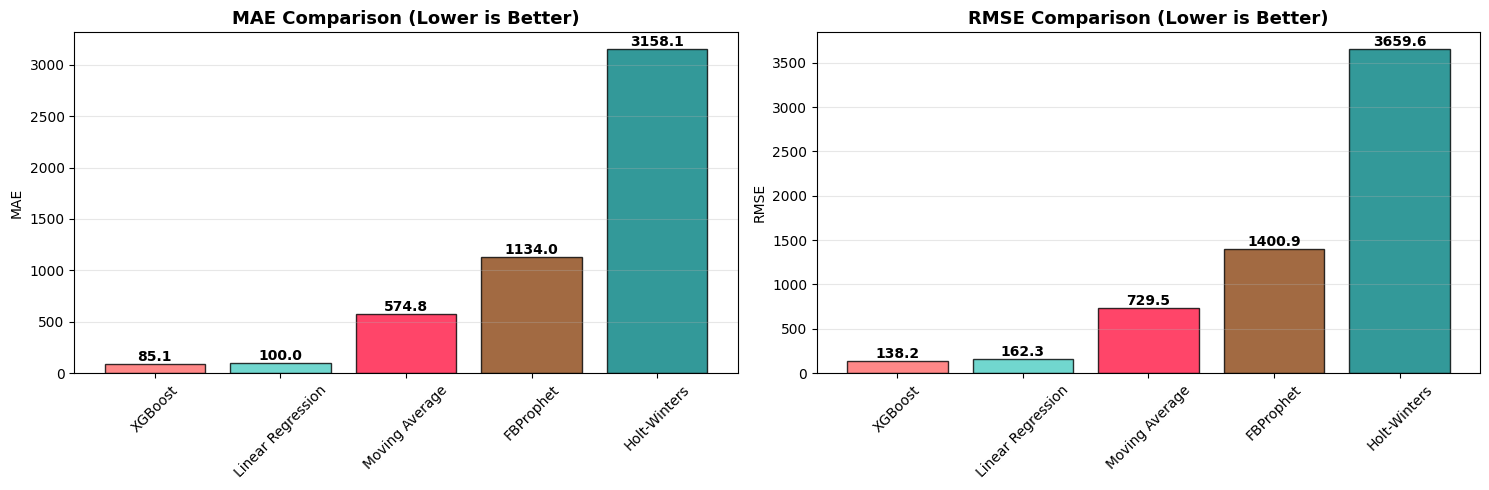

✓ Comparison plots complete!


In [ ]:
# 12. COMPARISON PLOTS
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#FF6B6B', '#4ECDC4', '#FF1744', '#8B4513', '#008080'] # Updated colors for 5 models

# MAE Comparison
bars1 = axes[0].bar(results_df['Model'], results_df['MAE'], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('MAE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

# RMSE Comparison
bars2 = axes[1].bar(results_df['Model'], results_df['RMSE'], color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Comparison plots complete!")

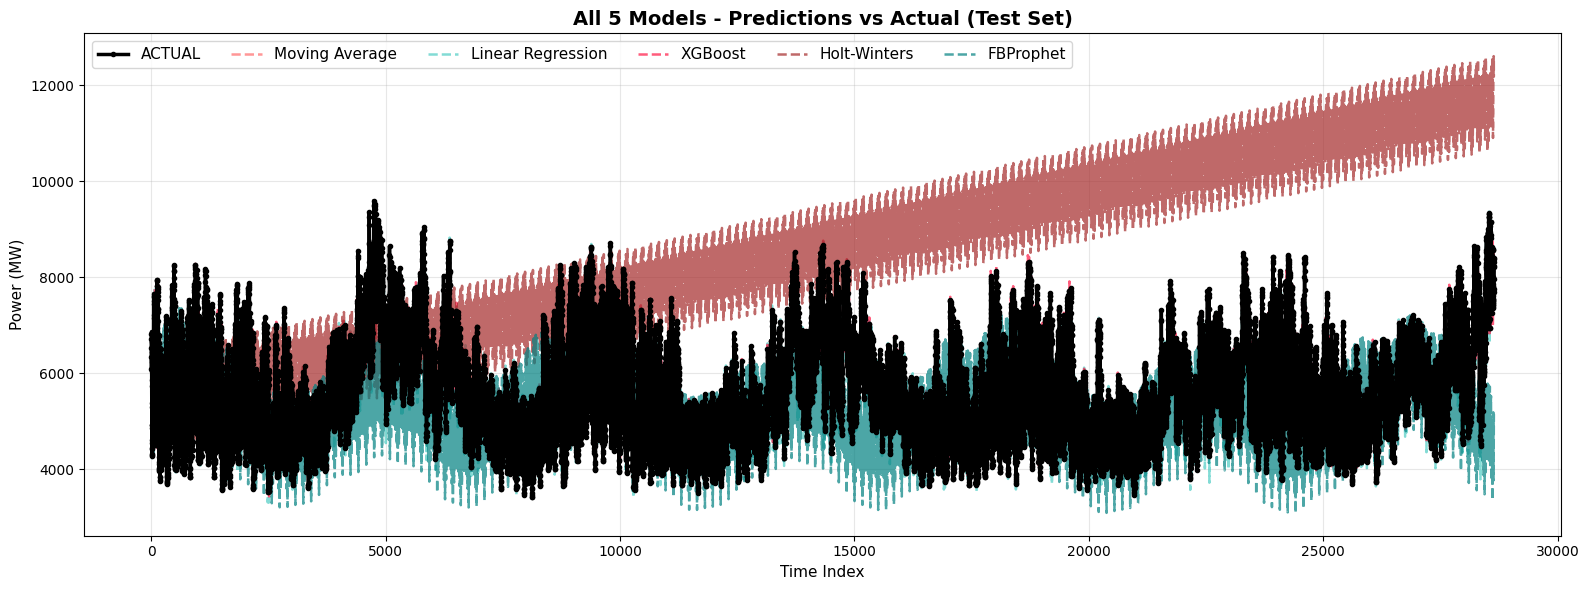

✓ All models overlay complete!


In [ ]:
# 13. ALL MODELS PREDICTIONS OVERLAY
fig, ax = plt.subplots(figsize=(16, 6))

test_indices = range(len(test_data))

ax.plot(test_indices, test_data, label='ACTUAL', linewidth=2.5, color='black', marker='o', markersize=3, zorder=10)
ax.plot(test_indices, predictions_ma, label='Moving Average', linewidth=1.8, color='#FF6B6B', linestyle='--', alpha=0.7)
ax.plot(test_indices, predictions_lr, label='Linear Regression', linewidth=1.8, color='#4ECDC4', linestyle='--', alpha=0.7)
ax.plot(test_indices, predictions_xgb, label='XGBoost', linewidth=1.8, color='#FF1744', linestyle='--', alpha=0.7)
ax.plot(test_indices, predictions_hw, label='Holt-Winters', linewidth=1.8, color='brown', linestyle='--', alpha=0.7)
ax.plot(test_indices, predictions_prophet, label='FBProphet', linewidth=1.8, color='teal', linestyle='--', alpha=0.7)

ax.set_title('All 5 Models - Predictions vs Actual (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Index', fontsize=11)
ax.set_ylabel('Power (MW)', fontsize=11)
ax.legend(fontsize=11, loc='best', ncol=6) # Increased ncol to accommodate more models
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ All models overlay complete!")

---

## SECTION 11: FORECAST NEXT 24 HOURS (Using Best Model)


NEXT 24 HOURS FORECAST (Using Best Model: XGBoost)

Forecast Comparison:
Hour  Actual  Moving Avg     Lin Reg     XGBoost  Holt-Winters   FBProphet
  H1    7469 8051.666667 7642.901323 7040.962402  11670.412219 4676.970702
  H2    7423 8049.083333 7264.188519 6973.528320  11339.392955 4717.537415
  H3    7380 8048.083333 7389.875868 7401.019043  11158.582318 4752.706216
  H4    7366 8044.375000 7454.140395 7462.753418  10953.342943 4780.362001
  H5    7428 8037.750000 7516.351519 7512.355957  10901.140858 4798.368997
  H6    7540 8026.000000 7659.547161 7751.132812  10943.193973 4824.235231
  H7    7658 8006.083333 7786.879408 7890.050293  11178.229038 4887.794439
  H8    7794 7976.250000 7805.513827 7987.791016  11570.508442 4999.449754
  H9    7825 7941.583333 7839.761009 8027.101074  11975.184804 5124.103759
 H10    7716 7909.500000 7786.833226 7789.807129  12081.136814 5189.866039
 H11    7614 7879.125000 7583.696109 7485.564453  12079.066216 5130.499821
 H12    7524 7850.333333 7

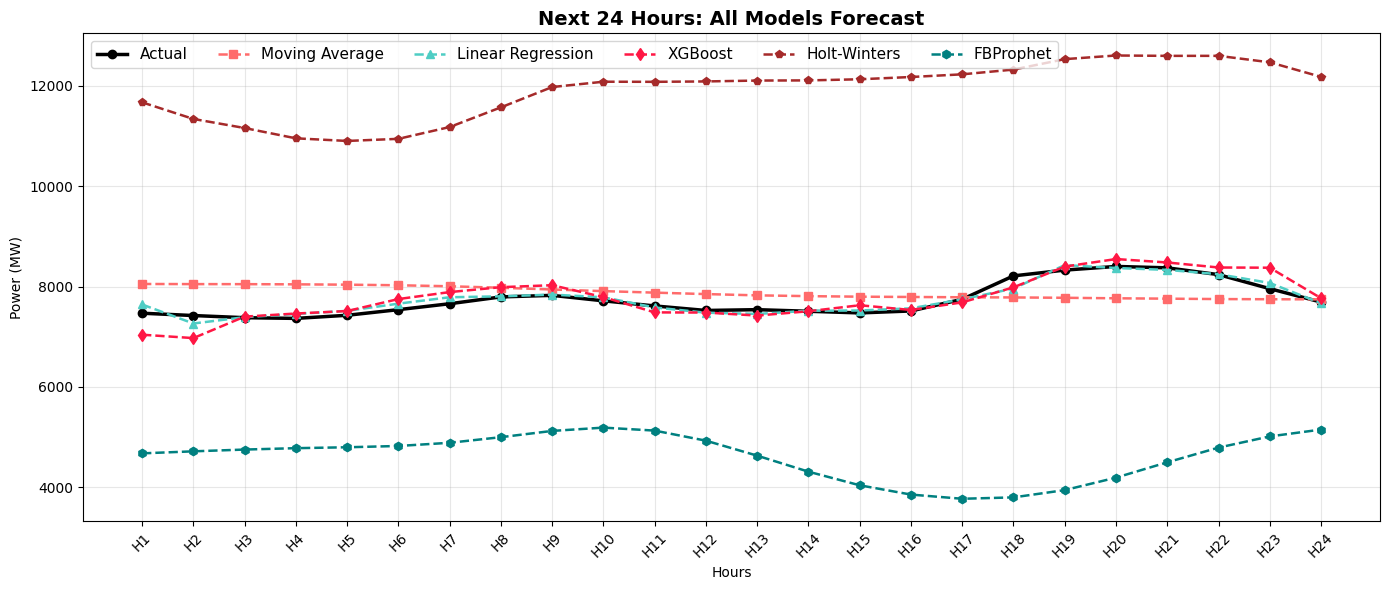


✓ Forecast complete!


In [ ]:
# 14. FORECAST NEXT 24 HOURS
print("\n" + "="*80)
print("NEXT 24 HOURS FORECAST (Using Best Model: " + best_model + ")")
print("="*80)

next_24_actual = test_data[-24:]
next_24_ma = predictions_ma[-24:]
next_24_lr = predictions_lr[-24:]
next_24_xgb = predictions_xgb[-24:]
# next_24_lstm = predictions_lstm[-24:] # Removed LSTM
next_24_hw = predictions_hw[-24:]
next_24_prophet = predictions_prophet[-24:]

forecast_df = pd.DataFrame({
    'Hour': [f"H{i+1}" for i in range(24)],
    'Actual': next_24_actual,
    'Moving Avg': next_24_ma,
    'Lin Reg': next_24_lr,
    'XGBoost': next_24_xgb,
    #'LSTM': next_24_lstm, # Removed LSTM
    'Holt-Winters': next_24_hw,
    'FBProphet': next_24_prophet
})

print("\nForecast Comparison:")
print(forecast_df.to_string(index=False))

# Plot forecast
fig, ax = plt.subplots(figsize=(14, 6))

hours_range = range(24)
ax.plot(hours_range, next_24_actual, label='Actual', linewidth=2.5, color='black', marker='o', markersize=6)
ax.plot(hours_range, next_24_ma, label='Moving Average', linewidth=1.8, color='#FF6B6B', linestyle='--', marker='s')
ax.plot(hours_range, next_24_lr, label='Linear Regression', linewidth=1.8, color='#4ECDC4', linestyle='--', marker='^')
ax.plot(hours_range, next_24_xgb, label='XGBoost', linewidth=1.8, color='#FF1744', linestyle='--', marker='d')
# ax.plot(hours_range, next_24_lstm, label='LSTM', linewidth=1.8, color='#45B7D1', linestyle='--', marker='v') # Removed LSTM
ax.plot(hours_range, next_24_hw, label='Holt-Winters', linewidth=1.8, color='brown', linestyle='--', marker='p')
ax.plot(hours_range, next_24_prophet, label='FBProphet', linewidth=1.8, color='teal', linestyle='--', marker='h')

ax.set_title('Next 24 Hours: All Models Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Hours')
ax.set_ylabel('Power (MW)')
ax.legend(fontsize=11, loc='best', ncol=6) # Adjusted ncol for 5 models
ax.grid(True, alpha=0.3)
ax.set_xticks(hours_range)
ax.set_xticklabels([f'H{i+1}' for i in range(24)], rotation=45)
plt.tight_layout()
plt.show()

print("\n✓ Forecast complete!")

---

## SECTION 12: STREAMLIT DEPLOYMENT

### 15. Save XGBoost Model and Scaler

To deploy the XGBoost model with Streamlit, we first need to save the trained model (`model_xgb`) and the scaler (`scaler_xgb`) that was used to preprocess the input features. This ensures consistency between training and deployment.

In [ ]:
# Save the trained XGBoost model and scaler
import joblib

# Define file paths
model_filename = 'xgboost_model.pkl'
scaler_filename = 'scaler_xgb.pkl'

# Save the model
joblib.dump(model_xgb, model_filename)
print(f"✓ XGBoost model saved to {model_filename}")

# Save the scaler
joblib.dump(scaler_xgb, scaler_filename)
print(f"✓ Scaler saved to {scaler_filename}")

✓ XGBoost model saved to xgboost_model.pkl
✓ Scaler saved to scaler_xgb.pkl


### 16. Create Streamlit Application File

Now, we'll create a Python script named `app.py` that will serve as our Streamlit application. This script will:

1.  Load the saved XGBoost model and scaler.
2.  Define the Streamlit user interface to accept input features.
3.  Preprocess the input using the loaded scaler.
4.  Make a prediction using the loaded model.
5.  Display the prediction to the user.

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(layout="wide")

st.title("PJMW Power Consumption Forecast - XGBoost Model")
st.write("This application forecasts future power consumption (MW) using a trained XGBoost model.")

# Load the trained model and scaler
@st.cache_resource
def load_model_and_scaler():
    try:
        model = joblib.load('xgboost_model.pkl')
        scaler = joblib.load('scaler_xgb.pkl')
        return model, scaler
    except FileNotFoundError:
        st.error("Model or scaler files not found. Please ensure 'xgboost_model.pkl' and 'scaler_xgb.pkl' are in the same directory.")
        st.stop()

model_xgb, scaler_xgb = load_model_and_scaler()

st.subheader("Enter the previous 24 hours of power consumption (MW):")

# Create 24 input fields dynamically in columns
cols = st.columns(6)
input_values = []

for i in range(24):
    with cols[i % 6]: # Distribute inputs across 6 columns
        value = st.number_input(f"Hour {i+1} (MW)", min_value=0.0, max_value=10000.0, value=5000.0, step=10.0, key=f'input_{i}')
        input_values.append(value)

if st.button("Forecast Next Hour"):
    if len(input_values) == 24:
        # Convert input to numpy array and reshape for scaler
        input_array = np.array(input_values).reshape(1, -1).astype(np.float32)

        # Scale the input features
        scaled_input = scaler_xgb.transform(input_array)

        # Make prediction
        prediction = model_xgb.predict(scaled_input)[0]

        st.success(f"The forecasted power consumption for the next hour is: **{prediction:.2f} MW**")
    else:
        st.error("Please provide input for all 24 hours.")

st.markdown("---")
st.write("Note: This forecast is based on the provided historical 24-hour window.")

Writing app.py


In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 63.4 MB/s eta 0:00:00


### 17. Run the Streamlit Application

To run your Streamlit application, execute the following command in your Colab terminal (or a local terminal if you've downloaded the `app.py` file):

```bash
!streamlit run app.py
```

When you run this command in Colab, it will provide a public URL that you can click to access your application in a new browser tab. Remember that the Streamlit app will only be active as long as your Colab session is running.

In [ ]:
!streamlit run app.py

/bin/bash: line 1: streamlit: command not found


In [ ]:
import sys

# Add the Streamlit directory to the Python path
# This is often necessary in Colab environments for Streamlit to be found
if 'streamlit' not in sys.modules:
    try:
        # Assuming Streamlit is installed in the default site-packages
        # You might need to adjust this path based on your Colab environment
        sys.path.append('/usr/local/lib/python3.10/dist-packages') # Common path for Streamlit in Colab
        import streamlit
        print("Streamlit module successfully imported after path adjustment.")
    except ImportError:
        print("Could not import Streamlit even after path adjustment. Please ensure it's installed correctly.")

# Now try to run Streamlit
!streamlit run app.py

Streamlit module successfully imported after path adjustment.


2026-06-16 14:54:51.926 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.11.164.232:8501

